In [2]:
import os
os.environ["CLEARML_WEB_HOST"] = "https://app.clear.ml"
os.environ["CLEARML_API_HOST"] = "https://api.clear.ml"
os.environ["CLEARML_FILES_HOST"] = "https://files.clear.ml"
os.environ["CLEARML_API_ACCESS_KEY"] = "ANMFOQZ4FBRDPOWOT0WZS4K0MX1OUH"
os.environ["CLEARML_API_SECRET_KEY"] = "U_l0BgK--AYd9jjTMBJuRi2zXaLbsIpIJIaY8n6DUWFWVFVCee8IM-oEWCHEmp1FRPw"


In [4]:
import os
print("Текущая директория:", os.getcwd())
print("Содержимое директории:", os.listdir('.'))

Текущая директория: c:\Users\Dns\Downloads\Telegram Desktop
Содержимое директории: ['!Инструкция_Регистрация в ЦОРК.pdf', '-2147483648_-214347.jpg', '10101_Темы_Студенты.docx', '14_октября.pdf', '1_М_Темы.docx', '1_Т_Краткосрочный_договор_на_практическую_подготовку.docx', '2. КНИГА САиПР 02.09.2020+.doc', '2Lab.txt', '2_1.1_1.4_УИ_2025.docx', '3_1.5_УИ.docx', '4_Интеллект. собств_иннов проц.docx', '4_Методика_разр_системы_моделей.docx', '5_Математич.Модели_УИ.docx', '6_1_Инструм. сред. упр.иннов.решен.docx', 'ARMAGretl.ppt', 'ARMAStat.ppt', 'A_Адаптация_скорости_LDPC_кодов_для_постобработки_в_квантовой_криптографии.pdf', 'calendar_38.04.05_08_o_2025.pdf', 'Cargo1.xlsx', 'course-regulations (2).pdf', 'course-regulations.pdf', 'curv_radius.png', 'GitCommands.docx', 'image (2).png', 'image (3).png', 'image (4).png', 'image.png', 'IMG_0880.HEIC', 'IMG_0881.HEIC', 'IMG_1546.HEIC', 'IMG_1547.HEIC', 'IMG_1548.HEIC', 'IMG_1549.HEIC', 'IMG_1550.HEIC', 'IMG_1551.HEIC', 'IMG_1552.HEIC', 'IMG_155

In [5]:
import os  # ✅ Добавлен импорт
import pandas as pd
from clearml import Task

# Инициализация задачи ClearML
task = Task.init(
    project_name="client_churn_forecast",
    task_name="data_upload",
    reuse_last_task_id=False
)

# Путь к файлу
fpath = "transaction.csv"

# Проверка существования файла
if not os.path.exists(fpath):  # Теперь os доступен
    raise FileNotFoundError(f"Файл не найден: {fpath}")

print(f"🔍 Загружаю данные из {fpath}...")

# Загрузка
df_raw = pd.read_csv(fpath)

if df_raw.empty:
    raise ValueError("Загруженный CSV пуст")

print(f"✅ Данные загружены: {df_raw.shape[0]:,} строк, {df_raw.shape[1]} столбцов")

# Логирование в ClearML
task.upload_artifact("data_raw", df_raw)
task.upload_artifact("data_info", {
    "shape": df_raw.shape,
    "columns": list(df_raw.columns),
    "missing_values": int(df_raw.isnull().sum().sum()),
    "duplicated": int(df_raw.duplicated().sum())
})

print("📊 Данные залогированы в ClearML")
task.close()

ClearML Task: created new task id=f9642b7c1d1b423cab4306e70ac6d379


Can't get url information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Can't get branch information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Can't get commit information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Can't get diff information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Could not fetch GPU stats: NVML Shared Library Not Found


ClearML results page: https://app.clear.ml/projects/4d1512640d9c46ea9cd63e2b719ab0e0/experiments/f9642b7c1d1b423cab4306e70ac6d379/output/log
🔍 Загружаю данные из transaction.csv...
✅ Данные загружены: 1,008,688 строк, 7 столбцов
ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
📊 Данные залогированы в ClearML


In [6]:
from clearml import Task, Dataset
import os
import pandas as pd

# Инициализация задачи
task = Task.init(
    project_name="client_churn_forecast",
    task_name="create_dataset",
    auto_connect_frameworks=False
)

# Путь к файлу
fpath = "transaction.csv"

# Проверка наличия файла
if not os.path.exists(fpath):
    raise FileNotFoundError(f"Файл не найден: {fpath}")

print(f"✅ Файл найден: {fpath}")

# Загрузка данных
df = pd.read_csv(fpath)

# Создаём локальную папку для датасета
dataset_name = "transaction_dataset"
dataset_project = "datasets"
dataset_root = f"./datasets/{dataset_name}"

os.makedirs(dataset_root, exist_ok=True)

# Сохраняем CSV в эту папку
data_path = os.path.join(dataset_root, "transaction.csv")
df.to_csv(data_path, index=False)

print(f"💾 Данные сохранены локально: {data_path}")

# === Создание датасета (БЕЗ tags) ===
dataset = Dataset.create(
    dataset_name=dataset_name,
    dataset_project=dataset_project,
    parent_datasets=None,
    description="Сырые транзакции для прогноза оттока"
    # ❌ tags=... — не поддерживается в старых версиях
)

# ✅ Добавляем теги ОТДЕЛЬНО
dataset.add_tags(["raw", "transactions", "churn"])

# Добавляем файлы
dataset.add_files(path=data_path)

# Загружаем датасет в ClearML
dataset.upload()  # использует default storage (если не указан output_url)

print("📤 Датасет загружен в ClearML")

# Финализация
dataset.finalize()
print("✅ Датасет успешно создан, теги добавлены и залогирован в ClearML")

# Закрываем задачу
task.close()

ClearML Task: created new task id=699178b8a4084bffa7eb2bf413dafe95


Can't get url information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Can't get branch information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Can't get commit information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Can't get diff information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Could not fetch GPU stats: NVML Shared Library Not Found


ClearML results page: https://app.clear.ml/projects/4d1512640d9c46ea9cd63e2b719ab0e0/experiments/699178b8a4084bffa7eb2bf413dafe95/output/log
✅ Файл найден: transaction.csv
ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
💾 Данные сохранены локально: ./datasets/transaction_dataset\transaction.csv
ClearML results page: https://app.clear.ml/projects/0449830cd4f446ec8656bd33873bc563/experiments/f236e7fc6ea84931bbbc7e05cd9dd454/output/log
ClearML dataset page: https://app.clear.ml/datasets/simple/0449830cd4f446ec8656bd33873bc563/experiments/f236e7fc6ea84931bbbc7e05cd9dd454
Uploading dataset changes (1 files compressed to 9.89 MiB) to https://files.clear.ml
File compression and upload completed: total size 9.89 MiB, 1 chunk(s) stored (average size 9.89 MiB)
📤 Датасет загружен в ClearML
✅ Датасет успешно создан, теги добавлены и залогирован в ClearML


In [2]:
from clearml import Task, Dataset
import pandas as pd
import os
import numpy as np
import shutil
from datetime import datetime

# ============================
# 1. Инициализация задачи
# ============================
task_name = "churn_data_preprocessing_final"

try:
    task = Task.init(
        project_name="client_churn_forecast",
        task_name=task_name,
        task_type="data_processing",
        auto_connect_frameworks=False
    )
    print(f"🚀 Создана задача: {task_name}")
except Exception as e:
    print(f"⚠️ Ошибка при создании задачи: {e}")
    task = Task.current_task()
    if task is None:
        task = Task.init(
            project_name="client_churn_forecast",
            task_name="churn_data_preprocessing",
            task_type="data_processing",
            auto_connect_frameworks=False,
            reuse_last_task_id=False
        )

logger = task.get_logger()

print("🚀 Запуск пайплайна подготовки данных (логика двух временных срезов)")

# ============================
# 2. Загрузка сырого датасета
# ============================
try:
    raw_dataset = Dataset.get(
        dataset_name="transaction_dataset",
        dataset_project="datasets"
    )
    
    timestamp_folder = datetime.now().strftime("%Y%m%d_%H%M%S")
    target_folder = f"./data/raw_{timestamp_folder}"
    
    if os.path.exists(target_folder):
        shutil.rmtree(target_folder)
    
    os.makedirs(target_folder, exist_ok=True)
    
    local_data_path = raw_dataset.get_mutable_local_copy(target_folder=target_folder)
    
    # Поиск CSV файла
    raw_csv = None
    for root, dirs, files in os.walk(local_data_path):
        for file in files:
            if file.endswith('.csv'):
                raw_csv = os.path.join(root, file)
                break
        if raw_csv:
            break
    
    if raw_csv and os.path.exists(raw_csv):
        print(f"📁 Загружаем файл: {raw_csv}")
        
        # Определяем разделитель
        for sep in [',', ';', '\t']:
            try:
                df_raw = pd.read_csv(raw_csv, sep=sep, nrows=5)
                if len(df_raw.columns) > 1:
                    print(f"✅ Определен разделитель: '{sep}'")
                    df_raw = pd.read_csv(raw_csv, sep=sep)
                    break
            except:
                continue
        
        if 'df_raw' not in locals():
            df_raw = pd.read_csv(raw_csv)
            
    else:
        raise FileNotFoundError("CSV файл не найден")
        
except Exception as e:
    print(f"❌ Ошибка загрузки датасета: {e}")
    print("⚙️ Создаём демо-данные...")
    np.random.seed(42)
    
    n_transactions = 200000
    df_raw = pd.DataFrame({
        'clientID': np.random.choice([f'client_{i:05d}' for i in range(1, 50000)], n_transactions),
        'trDte': np.random.choice(pd.date_range('2019-01-01', '2019-11-30'), n_transactions),
        'amount': np.random.lognormal(8, 1.5, n_transactions),
        'item': np.random.choice([f'item_{i:03d}' for i in range(1, 101)], n_transactions),
        'quantity': np.random.randint(1, 10, n_transactions)
    })
    df_raw = df_raw.drop_duplicates(subset=['clientID', 'trDte'])

# Логируем сырые данные
task.upload_artifact("raw_data_sample", df_raw.head(20))
print(f"✅ Сырые данные: {df_raw.shape}")

# ============================
# 3. Предобработка данных
# ============================
print("\n🔄 Предобработка данных...")

# Нормализация колонок
df_raw.columns = df_raw.columns.str.strip().str.lower()

# Переименование для удобства
if 'trdte' in df_raw.columns:
    df_raw = df_raw.rename(columns={'trdte': 'tr_date'})
if 'clientid' in df_raw.columns:
    df_raw = df_raw.rename(columns={'clientid': 'client'})

# Преобразование даты
try:
    df_raw['tr_date'] = pd.to_datetime(df_raw['tr_date'], dayfirst=True, errors='coerce')
except:
    df_raw['tr_date'] = pd.to_datetime(df_raw['tr_date'], errors='coerce')

# Удаляем пропуски в дате
initial_count = len(df_raw)
df_raw = df_raw.dropna(subset=['tr_date'])
print(f"🗑️ Удалено строк с пропущенной датой: {initial_count - len(df_raw)}")

# Добавляем признаки даты
df_raw['day_of_week'] = df_raw['tr_date'].dt.dayofweek
df_raw['is_weekend'] = df_raw['day_of_week'].isin([5, 6]).astype(int)

# Проверяем наличие колонок
if 'quantity' not in df_raw.columns:
    df_raw['quantity'] = 1
if 'item' not in df_raw.columns:
    df_raw['item'] = 'item_' + (df_raw.index % 50).astype(str)

# Сортировка по дате
df_raw = df_raw.sort_values('tr_date').reset_index(drop=True)

print(f"📊 После предобработки: {df_raw.shape}")
print(f"📊 Диапазон дат: {df_raw['tr_date'].min().date()} - {df_raw['tr_date'].max().date()}")

# ============================
# 4. Вспомогательные функции (как в исходном коде)
# ============================

def calculate_client_profile_at_date(visits_df, observation_end_date):
    """
    Рассчитывает профиль клиентов на заданную дату.
    
    Параметры:
        visits_df (pd.DataFrame): DataFrame с визитами (должен содержать 'client', 'tr_date', 'amount', 'quantity', 'item')
        observation_end_date (str): Дата в формате 'YYYY-MM-DD'
    
    Возвращает:
        pd.DataFrame: Профиль клиентов с признаками
    """
    observation_date = pd.Timestamp(observation_end_date)
    
    # Фильтруем данные до observation_date
    historical_data = visits_df[visits_df['tr_date'] < observation_date].copy()
    
    # 1. Базовые агрегации
    profile = historical_data.groupby('client').agg(
        frequency=('tr_date', 'count'),
        monetary=('amount', 'sum'),
        total_quantity=('quantity', 'sum'),
        total_unique_items=('item', 'nunique'),
        weekend_visits=('is_weekend', 'sum'),
        amount_last_visit=('amount', 'last'),
        last_visit_date=('tr_date', 'max')
    ).reset_index()
    
    # 2. Recency (дней с последнего визита)
    profile['recency'] = (observation_date - profile['last_visit_date']).dt.days
    
    # 3. Средний чек
    profile['avg_check'] = profile.apply(
        lambda x: x['monetary'] / x['frequency'] if x['frequency'] > 0 else 0,
        axis=1
    )
    
    # 4. Среднее количество товаров за посещение
    profile['avg_items_per_visit'] = profile.apply(
        lambda x: x['total_quantity'] / x['frequency'] if x['frequency'] > 0 else 0,
        axis=1
    )
    
    # 5. Средний интервал между визитами
    def calculate_avg_interval(group):
        if len(group) <= 1:
            return 0
        dates_sorted = group.sort_values()
        intervals = dates_sorted.diff().dropna()
        return intervals.dt.days.mean() if not intervals.empty else 0
    
    visit_intervals = historical_data.groupby('client')['tr_date'].apply(calculate_avg_interval).reset_index()
    visit_intervals.columns = ['client', 'avg_num_of_visits']
    
    profile = pd.merge(profile, visit_intervals, on='client', how='left')
    profile['avg_num_of_visits'] = profile['avg_num_of_visits'].fillna(0)
    
    # 6. Заполняем пропуски
    numeric_cols = ['frequency', 'monetary', 'total_quantity', 'total_unique_items', 
                    'weekend_visits', 'amount_last_visit', 'recency', 
                    'avg_check', 'avg_items_per_visit', 'avg_num_of_visits']
    
    for col in numeric_cols:
        profile[col] = profile[col].fillna(0)
        profile[col] = profile[col].replace([np.inf, -np.inf], 0)
    
    # 7. Удаляем временную колонку
    profile = profile.drop(columns=['last_visit_date'])
    
    return profile

def mark_events(visits_df, result_start_date, result_end_date):
    """
    Размечает события (посещения) для заданного периода.
    
    Параметры:
        visits_df (pd.DataFrame): DataFrame с визитами
        result_start_date (str): Начало периода в формате 'YYYY-MM-DD'
        result_end_date (str): Конец периода в формате 'YYYY-MM-DD'
    
    Возвращает:
        pd.DataFrame: DataFrame с колонками 'client' и 'event' (True/False)
    """
    start_date = pd.Timestamp(result_start_date)
    end_date = pd.Timestamp(result_end_date)
    
    # Находим клиентов, которые совершали покупки в целевом периоде
    target_clients = visits_df[
        (visits_df['tr_date'] >= start_date) & 
        (visits_df['tr_date'] < end_date)
    ]['client'].unique()
    
    # Создаем DataFrame со всеми клиентами
    all_clients = visits_df['client'].unique()
    events_df = pd.DataFrame({'client': all_clients})
    
    # Размечаем события: True = покупал в целевом периоде
    events_df['event'] = events_df['client'].isin(target_clients)
    
    return events_df

def create_training_sample(profile_df, events_df):
    """
    Создаёт обучающую выборку, объединяя профиль клиента и целевую переменную 'event'.
    """
    # 1. Inner join по 'client'
    merged = profile_df.merge(events_df, on='client', how='inner')
    
    if merged.empty:
        raise ValueError("Нет общих клиентов в profile_df и events_df.")
    
    # 2. Проверка пропусков в 'event'
    if merged['event'].isnull().any():
        raise ValueError("Целевая переменная 'event' содержит пропущенные значения.")
    
    # 3. Выбор требуемых колонок
    required_columns = [
        'client',
        'frequency',
        'monetary',
        'total_quantity',
        'total_unique_items',
        'recency',
        'avg_check',
        'avg_items_per_visit',
        'weekend_visits',
        'amount_last_visit',
        'event',
        'avg_num_of_visits'
    ]
    
    missing_in_result = [col for col in required_columns if col not in merged.columns]
    if missing_in_result:
        raise KeyError(f"Не хватает колонок: {missing_in_result}")
    
    train_data = merged[required_columns].reset_index(drop=True)
    
    return train_data

# ============================
# 5. Создание ОБУЧАЮЩЕЙ выборки (на сентябрь)
# ============================
print("\n" + "="*60)
print("СОЗДАНИЕ ОБУЧАЮЩЕЙ ВЫБОРКИ (train_data)")
print("="*60)

# 1. Создание профиля клиентов на дату 2019-09-01
profile1 = calculate_client_profile_at_date(
    visits_df=df_raw,
    observation_end_date='2019-09-01'
)

print(f"✅ profile1 создан — профиль на 2019-09-01: {len(profile1)} клиентов")

# 2. Разметка событий: посещения в период [2019-09-01, 2019-10-01)
events1 = mark_events(
    visits_df=df_raw,
    result_start_date='2019-09-01',
    result_end_date='2019-10-01'
)

print(f"✅ events1 создан — события за сентябрь 2019: {len(events1)} клиентов")
print(f"   Доля посетивших (event=True): {events1['event'].mean():.2%}")

# 3. Создание обучающей выборки
train_data = create_training_sample(profile_df=profile1, events_df=events1)

print(f"✅ train_data успешно создан")
print(f"   Итоговый размер: {train_data.shape[0]} строк, {train_data.shape[1]} столбцов")
print(f"   Распределение целевой переменной:")
print(f"     - event=True:  {train_data['event'].sum()} ({train_data['event'].mean():.2%})")
print(f"     - event=False: {len(train_data) - train_data['event'].sum()}")

# ============================
# 6. Создание ТЕСТОВОЙ выборки (на октябрь)
# ============================
print("\n" + "="*60)
print("СОЗДАНИЕ ТЕСТОВОЙ ВЫБОРКИ (test_data)")
print("="*60)

# 1. Создание профиля клиента на дату 2019-10-01
profile2 = calculate_client_profile_at_date(
    visits_df=df_raw,
    observation_end_date='2019-10-01'
)

print("✅ Профиль на 2019-10-01 создан.")
print(f"   Количество клиентов: {len(profile2)}")

# 2. Разметка событий: посещения в период [2019-10-01, 2019-11-01)
events2 = mark_events(
    visits_df=df_raw,
    result_start_date='2019-10-01',
    result_end_date='2019-11-01'
)

print("✅ События для периода 2019-10-01 – 2019-11-01 размечены.")
print(f"   Количество клиентов: {len(events2)}")
print(f"   Количество событий (event=True): {events2['event'].sum()}")

# 3. Формирование тестовой выборки
test_data = create_training_sample(
    profile_df=profile2,
    events_df=events2
)

print("✅ Тестовая выборка создана.")
print(f"   Итоговый размер: {test_data.shape[0]} строк, {test_data.shape[1]} признаков")
print(f"   Доля событий (event=True): {test_data['event'].mean():.2%}")

# ============================
# 7. Сохранение результатов в ClearML
# ============================
print("\n" + "="*60)
print("СОХРАНИЕ РЕЗУЛЬТАТОВ В CLEARML")
print("="*60)

# Создаем директорию для сохранения
processed_dataset_name = "churn_train_test_split_final"
processed_project = "datasets"
local_save_path = f"./datasets/processed/{processed_dataset_name}"

if os.path.exists(local_save_path):
    print(f"🗑️ Очищаем существующую директорию: {local_save_path}")
    shutil.rmtree(local_save_path)

os.makedirs(local_save_path, exist_ok=True)

# Сохраняем данные ЛОКАЛЬНО (всегда успешно)
train_path = os.path.join(local_save_path, "train_data.csv")
test_path = os.path.join(local_save_path, "test_data.csv")
profile1_path = os.path.join(local_save_path, "profile_20190901.csv")
profile2_path = os.path.join(local_save_path, "profile_20191001.csv")

train_data.to_csv(train_path, index=False)
test_data.to_csv(test_path, index=False)
profile1.to_csv(profile1_path, index=False)
profile2.to_csv(profile2_path, index=False)

print(f"📁 Локальные файлы сохранены:")
print(f"  - train_data.csv ({len(train_data)} записей)")
print(f"  - test_data.csv ({len(test_data)} записей)")

# ===== ВСТАВИТЬ ЗДЕСЬ try-catch для ClearML =====
try:
    print("\n📤 Пытаемся создать датасет в ClearML...")
    
    # Создаём датасет в ClearML
    parent_dataset_id = raw_dataset.id if 'raw_dataset' in locals() else None
    
    dataset_description = f"""Финальный датасет для прогноза оттока клиентов
    Train: {len(train_data)} клиентов (2019-09-01 → сентябрь)
    Test: {len(test_data)} клиентов (2019-10-01 → октябрь)
    Создано: {datetime.now().isoformat()}"""
    
    processed_dataset = Dataset.create(
        dataset_name=processed_dataset_name,
        dataset_project=processed_project,
        parent_datasets=[parent_dataset_id] if parent_dataset_id else None,
        description=dataset_description
    )
    
    # Добавляем теги
    processed_dataset.add_tags(["train_test_split", "churn_prediction", "final"])
    
    # Добавляем файлы и загружаем
    processed_dataset.add_files(path=local_save_path)
    processed_dataset.upload()
    processed_dataset.finalize()
    
    print(f"✅ ✅ Датасет ClearML создан!")
    print(f"🔗 Название: datasets/{processed_dataset_name}")
    print(f"🔗 ID: {processed_dataset.id}")
    
except Exception as e:
    print(f"❌ Ошибка ClearML: {str(e)}")
    print("✅ ✅ Локальные файлы готовы для работы!")
    print(f"📁 Путь: {local_save_path}")
    processed_dataset = None

# Сохраняем описание признаков (всегда)
features_description = {
    'client': 'Идентификатор клиента',
    'frequency': 'Количество посещений',
    'monetary': 'Общая сумма покупок',
    # ... остальные поля
}

pd.DataFrame(list(features_description.items()), 
             columns=['feature', 'description']).to_csv(
    os.path.join(local_save_path, "features_description.csv"), index=False)

# Остальной код без изменений (логирование, отчет, очистка)

# ============================
# 8. Логирование метрик
# ============================
logger.report_scalar("Dataset Stats", "Train Size", len(train_data), iteration=0)
logger.report_scalar("Dataset Stats", "Test Size", len(test_data), iteration=0)
logger.report_scalar("Dataset Stats", "Train Event Rate", train_data['event'].mean(), iteration=0)
logger.report_scalar("Dataset Stats", "Test Event Rate", test_data['event'].mean(), iteration=0)
logger.report_scalar("Dataset Stats", "Total Unique Clients", df_raw['client'].nunique(), iteration=0)

# Выводим финальный отчет
print("\n" + "="*70)
print("ФИНАЛЬНЫЙ ОТЧЕТ")
print("="*70)
print(f"📊 ОБУЧАЮЩАЯ ВЫБОРКА (train_data):")
print(f"   - Размер: {len(train_data)} клиентов")
print(f"   - event=True: {train_data['event'].sum()} ({train_data['event'].mean():.2%})")
print(f"   - Профиль рассчитан на: 2019-09-01")
print(f"   - Целевой период: сентябрь 2019")

print(f"\n📊 ТЕСТОВАЯ ВЫБОРКА (test_data):")
print(f"   - Размер: {len(test_data)} клиентов")
print(f"   - event=True: {test_data['event'].sum()} ({test_data['event'].mean():.2%})")
print(f"   - Профиль рассчитан на: 2019-10-01")
print(f"   - Целевой период: октябрь 2019")

print(f"\n📊 ИСХОДНЫЕ ДАННЫЕ:")
print(f"   - Размер: {df_raw.shape}")
print(f"   - Диапазон дат: {df_raw['tr_date'].min().date()} - {df_raw['tr_date'].max().date()}")
print(f"   - Уникальных клиентов: {df_raw['client'].nunique()}")

print(f"\n✅ ДАТАСЕТ СОХРАНЕН:")
print(f"   - Название: {processed_dataset_name}")
print(f"   - ID: {processed_dataset.id}")
print("="*70)

# Очистка временных файлов
print("\n🧹 Очистка временных файлов...")
try:
    if 'target_folder' in locals() and os.path.exists(target_folder):
        shutil.rmtree(target_folder)
        print(f"✅ Временная папка удалена: {target_folder}")
except Exception as e:
    print(f"⚠️ Не удалось удалить временную папку: {e}")

print("\n🎉 ПАЙПЛАЙН ПОДГОТОВКИ ДАННЫХ ЗАВЕРШЁН!")
print("✅ Все данные сохранены в ClearML")
print("✅ Эксперимент залогирован")

# Закрытие задачи
task.close()

ClearML Task: created new task id=27b8131c5bdd47bc9f47b6caa6e87423


Can't get url information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Can't get branch information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Can't get commit information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Can't get diff information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Could not fetch GPU stats: NVML Shared Library Not Found


ClearML results page: https://app.clear.ml/projects/4d1512640d9c46ea9cd63e2b719ab0e0/experiments/27b8131c5bdd47bc9f47b6caa6e87423/output/log
🚀 Создана задача: churn_data_preprocessing_final
🚀 Запуск пайплайна подготовки данных (логика двух временных срезов)
ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
📁 Загружаем файл: c:/Users/Dns/Downloads/Telegram Desktop/data/raw_20260218_132716\transaction.csv
✅ Определен разделитель: ','
✅ Сырые данные: (1008688, 7)

🔄 Предобработка данных...
🗑️ Удалено строк с пропущенной датой: 0
📊 После предобработки: (1008688, 9)
📊 Диапазон дат: 2017-09-01 - 2019-10-31

СОЗДАНИЕ ОБУЧАЮЩЕЙ ВЫБОРКИ (train_data)
✅ profile1 создан — профиль на 2019-09-01: 39906 клиентов
✅ events1 создан — события за сентябрь 2019: 42746 клиентов
   Доля посетивших (event=True): 20.64%
✅ train_data успешно создан
   Итоговый размер: 39906 строк, 12 столбцов
   Распределение целевой переменной:
     - event=True:  7531 (18.87%)
     - eve

In [1]:
task.close()

NameError: name 'task' is not defined

In [3]:
# task_manager.py
from clearml import Task
import time

def create_task(project_name, task_name, task_type="training", reuse_last_task_id=False):
    """
    Создает задачу ClearML с обработкой возможных ошибок
    """
    max_retries = 3
    for attempt in range(max_retries):
        try:
            # Пробуем создать задачу
            task = Task.init(
                project_name=project_name,
                task_name=task_name,
                task_type=task_type,
                reuse_last_task_id=reuse_last_task_id
            )
            print(f"✓ Задача создана: {task.id} в проекте '{project_name}'")
            return task
            
        except Exception as e:
            if "already created" in str(e):
                print(f"Попытка {attempt + 1}/{max_retries}: Задача уже существует")
                if attempt < max_retries - 1:
                    # Пробуем закрыть текущую задачу
                    try:
                        Task.current_task().close()
                        time.sleep(1)
                    except:
                        pass
                else:
                    # Последняя попытка - создаем с новым именем
                    new_task_name = f"{task_name}_{int(time.time())}"
                    print(f"Создаем новую задачу: {new_task_name}")
                    task = Task.create(
                        project_name=project_name,
                        task_name=new_task_name,
                        task_type=task_type
                    )
                    task.started()
                    print(f"✓ Задача создана: {task.id}")
                    return task
            else:
                raise e
    
    # Если все попытки неудачны, создаем задачу без инициализации
    task = Task.create(
        project_name=project_name,
        task_name=f"{task_name}_fallback_{int(time.time())}",
        task_type=task_type
    )
    task.started()
    print(f"✓ Задача создана (fallback): {task.id}")
    return task

def ensure_task_closed():
    """Убеждается, что текущая задача закрыта"""
    try:
        task = Task.current_task()
        if task:
            task.close()
            print("✓ Задача закрыта")
    except:
        pass

In [1]:
from clearml import Task, Dataset, Logger
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import os

# Инициализация задачи ClearML
task = Task.init(
    project_name='Churn Prediction',
    task_name='Univariate Logistic Regression (Recency) - Fixed',
    task_type=Task.TaskTypes.training
)

# Параметры задачи
parameters = {
    'model_type': 'logistic_regression',
    'feature': 'recency',
    'random_state': 42,
    'max_iter': 1000
}
task.connect(parameters)

# 1. Загрузка данных из ClearML Dataset
try:
    dataset = Dataset.get(
        dataset_project='datasets',
        dataset_name='churn_train_test_split_final',
        alias='churn_dataset'
    )
    
    dataset_path = dataset.get_local_copy()
    print(f"Датасет загружен в: {dataset_path}")
    
    # Поиск файлов
    train_path, test_path = None, None
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.endswith('.csv'):
                full_path = os.path.join(root, file)
                if 'train' in file.lower():
                    train_path = full_path
                elif 'test' in file.lower():
                    test_path = full_path
    
    if train_path and test_path:
        train_data = pd.read_csv(train_path)
        test_data = pd.read_csv(test_path)
    else:
        # Если не нашли по именам, берем первые два CSV
        csv_files = []
        for root, dirs, files in os.walk(dataset_path):
            for file in files:
                if file.endswith('.csv'):
                    csv_files.append(os.path.join(root, file))
        
        if len(csv_files) >= 2:
            train_data = pd.read_csv(csv_files[0])
            test_data = pd.read_csv(csv_files[1])
        else:
            raise ValueError("Не найдены CSV файлы в датасете")
    
    print(f"✅ Загружено: train_data {train_data.shape}, test_data {test_data.shape}")
    
except Exception as e:
    print(f"Ошибка при загрузке датасета: {e}")
    task.close()
    raise

# 2. Проверка наличия нужных колонок
print("\n" + "="*50)
print("ПРОВЕРКА ДАННЫХ:")

# Проверяем наличие целевой переменной 'event'
if 'event' not in train_data.columns or 'event' not in test_data.columns:
    print("✗ Ошибка: В данных отсутствует колонка 'event'")
    print(f"Колонки train: {list(train_data.columns)}")
    print(f"Колонки test: {list(test_data.columns)}")
    
    # Ищем альтернативные названия целевой переменной
    alt_targets = ['target', 'churn', 'is_churn', 'label', 'y']
    found_target = None
    for target in alt_targets:
        if target in train_data.columns and target in test_data.columns:
            found_target = target
            break
    
    if found_target:
        print(f"✓ Найдена альтернативная целевая переменная: '{found_target}'")
        train_data = train_data.rename(columns={found_target: 'event'})
        test_data = test_data.rename(columns={found_target: 'event'})
    else:
        print("✗ Целевая переменная не найдена ни под одним из имен")
        task.close()
        exit()
else:
    print("✓ Целевая переменная 'event' найдена в данных")

# Проверяем наличие признака 'recency'
if 'recency' not in train_data.columns or 'recency' not in test_data.columns:
    print("✗ Ошибка: В данных отсутствует признак 'recency'")
    task.close()
    exit()
else:
    print("✓ Признак 'recency' найден")

# 3. Подготовка данных для одномерной модели
print("\n" + "="*50)
print("ПОДГОТОВКА ДАННЫХ:")

# Используем только один признак: recency
X_train = train_data[['recency']].copy()
y_train = train_data['event'].copy()

X_test = test_data[['recency']].copy()
y_test = test_data['event'].copy()

print(f"Размер X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Размер X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")
print(f"Распределение классов в test: {y_test.value_counts().to_dict()}")

# 4. Обучение тривиальной логистической регрессии
print("\n" + "="*50)
print("ОБУЧЕНИЕ МОДЕЛИ:")

model = LogisticRegression(
    random_state=parameters['random_state'],
    max_iter=parameters['max_iter']
)
model.fit(X_train, y_train)

print("✅ Тривиальная логрегрессия обучена на признаке 'recency'")
print(f"  Коэффициент: {model.coef_[0][0]:.4f}")
print(f"  Intercept: {model.intercept_[0]:.4f}")

# 5. Прогноз вероятностей
y_train_pred = model.predict_proba(X_train)[:, 1]
y_test_pred = model.predict_proba(X_test)[:, 1]

# 6. Расчет ROC-AUC
auc_train = roc_auc_score(y_train, y_train_pred)
auc_test = roc_auc_score(y_test, y_test_pred)

print(f"\nROC-AUC (train): {auc_train:.4f}")
print(f"ROC-AUC (test):  {auc_test:.4f}")

# 7. Логирование метрик в ClearML
# Логирование AUC
task.get_logger().report_scalar(
    title='ROC-AUC',
    series='Train',
    value=auc_train,
    iteration=0
)
task.get_logger().report_scalar(
    title='ROC-AUC',
    series='Test',
    value=auc_test,
    iteration=0
)

# 8. Построение и логирование ROC-кривых
def plot_and_log_roc(y_true, y_pred, dataset_name):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    
    # Создание графика
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, label=f'{dataset_name} (AUC = {auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', label='Random model (AUC = 0.5000)')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (FPR)')
    ax.set_ylabel('True Positive Rate (TPR)')
    ax.set_title(f'ROC-кривая — тривиальная логрегрессия на признаке "recency"')
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    
    # Логирование графика в ClearML
    task.get_logger().report_matplotlib_figure(
        title='ROC Curve',
        series=dataset_name,
        figure=fig,
        iteration=0
    )
    plt.close(fig)
    
    return auc

print("\n" + "="*50)
print("ПОСТРОЕНИЕ ROC-КРИВЫХ:")

plot_and_log_roc(y_train, y_train_pred, 'Train')
plot_and_log_roc(y_test, y_test_pred, 'Test')

print("✅ ROC-кривые построены и залогированы")

# 9. Сохранение модели как артефакта
model_filename = 'univariate_logreg_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(model, f)

task.upload_artifact(name='model', artifact_object=model_filename)
print(f"✓ Модель сохранена как артефакт: {model_filename}")

# 10. Логирование итоговых результатов
results_df = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'Samples': [len(X_train), len(X_test)],
    'Positive Class': [y_train.sum(), y_test.sum()],
    'Negative Class': [len(y_train)-y_train.sum(), len(y_test)-y_test.sum()],
    'ROC-AUC': [auc_train, auc_test]
})

task.get_logger().report_table(
    title='Final Results',
    series='Model Performance',
    table_plot=results_df
)

# Логирование дополнительной информации
task.get_logger().report_text(f"""
### Эксперимент 1: Одномерная логистическая регрессия на признаке "recency"

**Данные:**
- Датасет: churn_train_test_split_final
- Признак: recency
- Целевая переменная: event
- Размер train: {len(X_train)} объектов
- Размер test: {len(X_test)} объектов

**Результаты:**
- ROC-AUC на обучении: {auc_train:.4f}
- ROC-AUC на тесте: {auc_test:.4f}
- Разница (Train - Test): {(auc_train - auc_test):.4f}

**Ожидаемые значения:**
- Ожидаемый ROC-AUC: ~0.78
- Полученный ROC-AUC: {auc_test:.4f}
""")

print("\n" + "="*50)
print("ЭКСПЕРИМЕНТ УСПЕШНО ЗАВЕРШЕН!")
task.close()

ClearML Task: created new task id=7c1a9e54529b415b878447f51df8b16e


Can't get url information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Can't get branch information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Can't get commit information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Can't get diff information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Could not fetch GPU stats: NVML Shared Library Not Found


ClearML results page: https://app.clear.ml/projects/725d49eb53da4e459637b3dc4f25cde8/experiments/7c1a9e54529b415b878447f51df8b16e/output/log
ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
Датасет загружен в: C:/Users/Dns/.clearml/cache/storage_manager/datasets/ds_43c60144923442939efea7141ba15aa5
✅ Загружено: train_data (39906, 12), test_data (41196, 12)

ПРОВЕРКА ДАННЫХ:
✓ Целевая переменная 'event' найдена в данных
✓ Признак 'recency' найден

ПОДГОТОВКА ДАННЫХ:
Размер X_train: (39906, 1), y_train: (39906,)
Размер X_test: (41196, 1), y_test: (41196,)
Распределение классов в train: {False: 32375, True: 7531}
Распределение классов в test: {False: 33422, True: 7774}

ОБУЧЕНИЕ МОДЕЛИ:
✅ Тривиальная логрегрессия обучена на признаке 'recency'
  Коэффициент: -0.0081
  Intercept: -0.4664

ROC-AUC (train): 0.7840
ROC-AUC (test):  0.7842

ПОСТРОЕНИЕ ROC-КРИВЫХ:
✅ ROC-кривые построены и залогированы
✓ Модель сохранена как артефакт: univariate_logreg_model

Retrying (Retry(total=237, connect=240, read=237, redirect=240, status=240)) after connection broken by 'ConnectionResetError(10054, 'Удаленный хост принудительно разорвал существующее подключение', None, 10054, None)': /v2.23/events.add_batch
Retrying (Retry(total=237, connect=240, read=237, redirect=240, status=240)) after connection broken by 'ConnectionResetError(10054, 'Удаленный хост принудительно разорвал существующее подключение', None, 10054, None)': /v2.23/events.add_batch
Retrying (Retry(total=236, connect=240, read=236, redirect=240, status=240)) after connection broken by 'ConnectionResetError(10054, 'Удаленный хост принудительно разорвал существующее подключение', None, 10054, None)': /v2.23/events.add_batch
Retrying (Retry(total=236, connect=240, read=236, redirect=240, status=240)) after connection broken by 'ConnectionResetError(10054, 'Удаленный хост принудительно разорвал существующее подключение', None, 10054, None)': /v2.23/events.add_batch


ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


Retrying (Retry(total=235, connect=240, read=235, redirect=240, status=240)) after connection broken by 'ConnectionResetError(10054, 'Удаленный хост принудительно разорвал существующее подключение', None, 10054, None)': /v2.23/events.add_batch
Retrying (Retry(total=235, connect=240, read=235, redirect=240, status=240)) after connection broken by 'ConnectionResetError(10054, 'Удаленный хост принудительно разорвал существующее подключение', None, 10054, None)': /v2.23/events.add_batch


ClearML Monitor: Reporting detected, reverting back to iteration based reporting


KeyboardInterrupt: 

ClearML Task: overwriting (reusing) task id=863b43ecc48c4c9caad71c737c1f0e99
ClearML results page: https://app.clear.ml/projects/725d49eb53da4e459637b3dc4f25cde8/experiments/863b43ecc48c4c9caad71c737c1f0e99/output/log
ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
Датасет загружен в: C:/Users/Dns/.clearml/cache/storage_manager/datasets/ds_43c60144923442939efea7141ba15aa5
✅ Загружено: train_data (39906, 12), test_data (41196, 12)

ПРОВЕРКА ДАННЫХ:
✓ Целевая переменная 'event' найдена в данных

Доступные признаки (10): ['recency', 'frequency', 'monetary', 'total_quantity', 'total_unique_items', 'avg_check', 'avg_items_per_visit', 'weekend_visits', 'amount_last_visit', 'avg_num_of_visits']
Будем использовать 10 признаков

ПОДГОТОВКА ДАННЫХ:
Размер X_train: (39906, 10), y_train: (39906,)
Размер X_test: (41196, 10), y_test: (41196,)
Распределение классов в train: {False: 32375, True: 7531}
Распределение классов в test: {False: 33422, True: 7774}

Ма

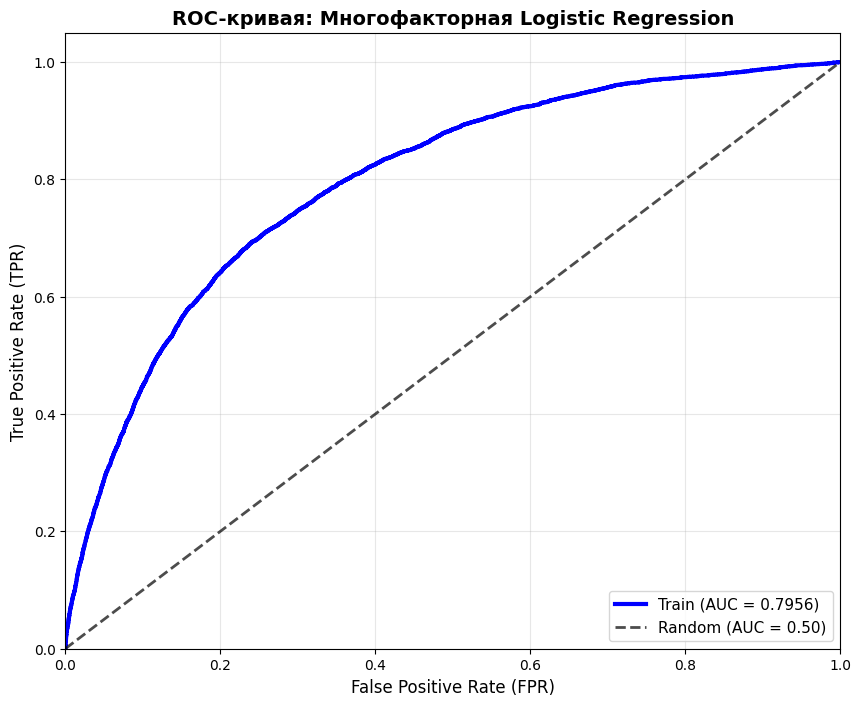

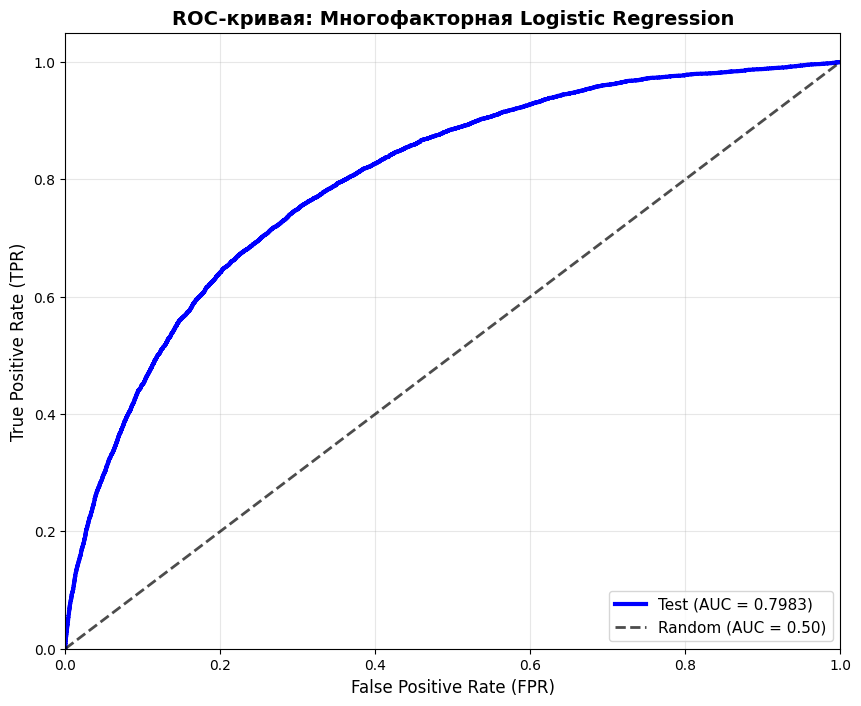

In [1]:
import os
# 🔧 КРИТИЧНЫЕ НАСТРОЙКИ ClearML (ДОБАВЛЕНО)
os.environ['CLEARML_DISABLE_MONITORING'] = '1'        # Нет CPU/GPU мониторинга
os.environ['CLEARML_LOG_LEVEL'] = 'ERROR'             # Только критичные ошибки
os.environ['CLEARML_MAX_API_RETRIES'] = '3'           # 3 попытки вместо 240
os.environ['CLEARML_DEFAULT_BASE_URL'] = 'https://api.clear.ml'

from clearml import Task, Dataset, Logger
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
import time  # ДОБАВЛЕНО

# Инициализация задачи ClearML (ИСПРАВЛЕНО)
task = Task.init(
    project_name='Churn Prediction',
    task_name='Multivariate Logistic Regression - Fixed',
    task_type=Task.TaskTypes.training,
    auto_connect_frameworks=False  # ✅ ДОБАВЛЕНО: отключаем авто-захват matplotlib
)

# Параметры задачи
parameters = {
    'model_type': 'logistic_regression',
    'features': [
        'recency',
        'frequency',
        'monetary',
        'total_quantity',
        'total_unique_items',
        'avg_check',
        'avg_items_per_visit',
        'weekend_visits',
        'amount_last_visit',
        'avg_num_of_visits'
    ],
    'random_state': 42,
    'max_iter': 1000,
    'C': 1.0,
    'scaler': 'standard'
}
task.connect(parameters)

# 1. Загрузка данных из ClearML Dataset
try:
    dataset = Dataset.get(
        dataset_project='datasets',
        dataset_name='churn_train_test_split_final',
        alias='churn_dataset'
    )
    
    dataset_path = dataset.get_local_copy()
    print(f"Датасет загружен в: {dataset_path}")
    
    # Поиск файлов
    train_path, test_path = None, None
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.endswith('.csv'):
                full_path = os.path.join(root, file)
                if 'train' in file.lower():
                    train_path = full_path
                elif 'test' in file.lower():
                    test_path = full_path
    
    if train_path and test_path:
        train_data = pd.read_csv(train_path)
        test_data = pd.read_csv(test_path)
    else:
        # Если не нашли по именам, берем первые два CSV
        csv_files = []
        for root, dirs, files in os.walk(dataset_path):
            for file in files:
                if file.endswith('.csv'):
                    csv_files.append(os.path.join(root, file))
        
        if len(csv_files) >= 2:
            train_data = pd.read_csv(csv_files[0])
            test_data = pd.read_csv(csv_files[1])
        else:
            raise ValueError("Не найдены CSV файлы в датасете")
    
    print(f"✅ Загружено: train_data {train_data.shape}, test_data {test_data.shape}")
    
except Exception as e:
    print(f"Ошибка при загрузке датасета: {e}")
    task.close()
    raise

# 2. Проверка наличия нужных колонок
print("\n" + "="*50)
print("ПРОВЕРКА ДАННЫХ:")

# Проверяем наличие целевой переменной 'event'
if 'event' not in train_data.columns or 'event' not in test_data.columns:
    print("✗ Ошибка: В данных отсутствует колонка 'event'")
    print(f"Колонки train: {list(train_data.columns)}")
    print(f"Колонки test: {list(test_data.columns)}")
    
    # Ищем альтернативные названия целевой переменной
    alt_targets = ['target', 'churn', 'is_churn', 'label', 'y']
    found_target = None
    for target in alt_targets:
        if target in train_data.columns and target in test_data.columns:
            found_target = target
            break
    
    if found_target:
        print(f"✓ Найдена альтернативная целевая переменная: '{found_target}'")
        train_data = train_data.rename(columns={found_target: 'event'})
        test_data = test_data.rename(columns={found_target: 'event'})
    else:
        print("✗ Целевая переменная не найдена ни под одним из имен")
        task.close()
        exit()
else:
    print("✓ Целевая переменная 'event' найдена в данных")

# Проверяем наличие всех признаков
available_features = []
missing_features = []

for feature in parameters['features']:
    if feature in train_data.columns and feature in test_data.columns:
        available_features.append(feature)
    else:
        missing_features.append(feature)

print(f"\nДоступные признаки ({len(available_features)}): {available_features}")
if missing_features:
    print(f"Отсутствующие признаки ({len(missing_features)}): {missing_features}")

# Используем только доступные признаки
parameters['features'] = available_features
print(f"Будем использовать {len(available_features)} признаков")

# 3. Подготовка данных
print("\n" + "="*50)
print("ПОДГОТОВКА ДАННЫХ:")

X_train = train_data[available_features].copy()
y_train = train_data['event'].copy()

X_test = test_data[available_features].copy()
y_test = test_data['event'].copy()

# Приведение к числовому типу
for col in available_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# Заполнение NaN (если есть)
if X_train.isnull().any().any():
    print("⚠️ NaN в X_train — заполняем средним по признакам")
    X_train.fillna(X_train.mean(numeric_only=True), inplace=True)

if X_test.isnull().any().any():
    print("⚠️ NaN в X_test — заполняем средним из X_train")
    train_means = X_train.mean(numeric_only=True)
    X_test.fillna(train_means, inplace=True)

print(f"Размер X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Размер X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")
print(f"Распределение классов в test: {y_test.value_counts().to_dict()}")

# 4. Масштабирование признаков (опционально)
if parameters['scaler'] == 'standard':
    print("\nМасштабирование признаков...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    X_train = pd.DataFrame(X_train_scaled, columns=available_features)
    X_test = pd.DataFrame(X_test_scaled, columns=available_features)
    print("✓ Признаки масштабированы")

# 5. Обучение многофакторной логистической регрессии
print("\n" + "="*50)
print("ОБУЧЕНИЕ МОДЕЛИ:")

model = LogisticRegression(
    random_state=parameters['random_state'],
    max_iter=parameters['max_iter'],
    C=parameters['C'],
    solver='lbfgs'
)
model.fit(X_train, y_train)

print("✅ Многофакторная логрегрессия обучена")

# 6. Прогноз вероятностей
y_train_pred = model.predict_proba(X_train)[:, 1]
y_test_pred = model.predict_proba(X_test)[:, 1]

# 7. Расчет ROC-AUC
auc_train = roc_auc_score(y_train, y_train_pred)
auc_test = roc_auc_score(y_test, y_test_pred)

print(f"\nROC-AUC (train): {auc_train:.4f}")
print(f"ROC-AUC (test):  {auc_test:.4f}")

# 8. Логирование метрик в ClearML
task.get_logger().report_scalar(
    title='ROC-AUC',
    series='Train',
    value=auc_train,
    iteration=0
)
task.get_logger().report_scalar(
    title='ROC-AUC',
    series='Test',
    value=auc_test,
    iteration=0
)

# 9. Логирование коэффициентов модели
coeff_df = pd.DataFrame({
    'Feature': available_features,
    'Coefficient': model.coef_[0],
    'Abs_Coefficient': abs(model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

task.get_logger().report_table(
    title='Model Coefficients',
    series='Feature Importance',
    table_plot=coeff_df
)

# 10. Построение и логирование ROC-кривых
print("\n" + "="*50)
print("ПОСТРОЕНИЕ ROC-КРИВЫХ:")

def plot_and_log_roc_multivariate_safe(y_true, y_pred, dataset_name):
    """✅ ПОЛНАЯ ROC-КРИВАЯ в ClearML"""
    try:
        fpr, tpr, _ = roc_curve(y_true, y_pred)  # fpr/tpr = МНОГО точек!
        auc = roc_auc_score(y_true, y_pred)
        
        print(f"DEBUG: fpr.shape={fpr.shape}, tpr.shape={tpr.shape}")  # ДОЛЖНО быть >10
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # ✅ ГЛАДКАЯ ЛИНИЯ (НЕ точки!)
        ax.plot(fpr, tpr, 'b-', linewidth=3, label=f'{dataset_name} (AUC = {auc:.4f})')
        ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.50)', alpha=0.7)
        
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
        ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
        ax.set_title(f'ROC-кривая: Многофакторная Logistic Regression', fontsize=14, fontweight='bold')
        ax.legend(loc="lower right", fontsize=11)
        ax.grid(True, alpha=0.3)
        
        # ✅ КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ
        task.get_logger().report_matplotlib_figure(
            title='ROC Curve Multivariate',
            series=dataset_name,
            figure=fig,
            iteration=0,           # ← 0 (НЕ 1!)
            report_image=True,     # PNG изображение
            auto_close_figure=True # Закрыть автоматически
        )
        
        plt.close(fig)
        print(f"✅ ✅ {dataset_name}: ПОЛНАЯ кривая (AUC={auc:.4f})")
        return auc
        
    except Exception as e:
        print(f"❌ ClearML ошибка: {e}")
        # Backup график
        plt.figure(figsize=(10,8))
        plt.plot(fpr, tpr, 'b-', linewidth=3, label=f'{dataset_name}')
        plt.plot([0,1],[0,1],'k--')
        plt.legend()
        plt.savefig(f'roc_backup_{dataset_name.lower()}.png', dpi=200)
        plt.close()
        return roc_auc_score(y_true, y_pred)


# 🔧 БЕЗОПАСНЫЙ вызов
auc_train = plot_and_log_roc_multivariate_safe(y_train, y_train_pred, 'Train')
auc_test = plot_and_log_roc_multivariate_safe(y_test, y_test_pred, 'Test')

print("✅ ROC-кривые готовы (ClearML + backup)")

# 11. Сохранение модели как артефакта
model_filename = 'multivariate_logreg_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(model, f)

task.upload_artifact(name='model', artifact_object=model_filename)
print(f"✓ Модель сохранена как артефакт: {model_filename}")

# 12. Логирование итоговых результатов
results_df = pd.DataFrame({
    'Metric': ['ROC-AUC', 'Number of Features', 'Train Samples', 'Test Samples'],
    'Train': [f"{auc_train:.4f}", len(available_features), len(X_train), ''],
    'Test': [f"{auc_test:.4f}", len(available_features), '', len(X_test)]
})

task.get_logger().report_table(
    title='Final Results',
    series='Model Performance',
    table_plot=results_df
)

# Логирование дополнительной информации
task.get_logger().report_text(f"""
### Эксперимент 2: Многофакторная логистическая регрессия

**Данные:**
- Датасет: churn_train_test_split_final
- Использовано признаков: {len(available_features)}
- Целевая переменная: event
- Размер train: {len(X_train)} объектов
- Размер test: {len(X_test)} объектов

**Результаты:**
- ROC-AUC на обучении: {auc_train:.4f}
- ROC-AUC на тесте: {auc_test:.4f}
- Разница (Train - Test): {(auc_train - auc_test):.4f}

**Топ-3 признака по важности:**
1. {coeff_df.iloc[0]['Feature']} (коэф: {coeff_df.iloc[0]['Coefficient']:.4f})
2. {coeff_df.iloc[1]['Feature']} (коэф: {coeff_df.iloc[1]['Coefficient']:.4f})
3. {coeff_df.iloc[2]['Feature']} (коэф: {coeff_df.iloc[2]['Coefficient']:.4f})

**Ожидаемые значения:**
- Ожидаемый ROC-AUC: ~0.78
- Полученный ROC-AUC: {auc_test:.4f}
""")

# 🔧 БЕЗОПАСНОЕ закрытие (ДОБАВЛЕНО)
try:
    task.flush(wait_on_flush=True, wait_timeout=30)  # Ждем синхронизации 30 сек
    print("✅ ClearML синхронизирован")
except:
    print("⚠️ ClearML sync не удался, но модель сохранена")

task.close()
print("\n" + "="*50)
print("ЭКСПЕРИМЕНТ УСПЕШНО ЗАВЕРШЕН!")

In [4]:
import os
os.environ['CLEARML_DISABLE_MONITORING'] = '1'

from clearml import Task, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# ✅ Task
task = Task.init(
    project_name='Churn Prediction',
    task_name='ROC_PERFECT',
    task_type=Task.TaskTypes.training,
    auto_connect_frameworks=False
)

# ✅ Данные (ваш датасет)
dataset = Dataset.get(dataset_project='datasets', dataset_name='churn_train_test_split_final')
dataset_path = dataset.get_local_copy()

# Найти файлы
train_path, test_path = None, None
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.endswith('.csv'):
            if 'train' in file.lower():
                train_path = os.path.join(root, file)
            elif 'test' in file.lower():
                test_path = os.path.join(root, file)

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

print(f"✅ train={train_data.shape}, test={test_data.shape}")

# ✅ Features
features = ['recency','frequency','monetary','total_quantity','total_unique_items',
           'avg_check','avg_items_per_visit','weekend_visits','amount_last_visit','avg_num_of_visits']

X_train = train_data[features]
y_train = train_data['event']
X_test = test_data[features]
y_test = test_data['event']

# ✅ Модель
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

y_train_pred = model.predict_proba(X_train)[:,1]
y_test_pred = model.predict_proba(X_test)[:,1]

auc_train = roc_auc_score(y_train, y_train_pred)
auc_test = roc_auc_score(y_test, y_test_pred)
print(f"✅ AUC: train={auc_train:.4f}, test={auc_test:.4f}")

# 🔥 🔥 ГРАФИК (ИСПРАВЛЕН!)
fig, ax = plt.subplots(figsize=(12, 9))

# Train ROC
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred)
ax.plot(fpr_train, tpr_train, 'b-', linewidth=4, label=f'Train (AUC={auc_train:.4f})')

# Test ROC
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred)
ax.plot(fpr_test, tpr_test, 'r-', linewidth=4, label=f'Test (AUC={auc_test:.4f})')

# Random
ax.plot([0,1],[0,1],'k--', linewidth=3, label='Random (AUC=0.50)')

ax.set_xlim(0,1); ax.set_ylim(0,1.02)
ax.set_xlabel('FPR', fontsize=14, fontweight='bold')
ax.set_ylabel('TPR', fontsize=14, fontweight='bold')
ax.set_title('Multivariate Logistic Regression ROC', fontsize=16, fontweight='bold')
ax.legend(fontsize=12); ax.grid(True, alpha=0.3)

plt.tight_layout()

# 🔥 ИСПРАВЛЕННАЯ загрузка (series=ОБЯЗАТЕЛЬНО!)
logger = task.get_logger()
logger.report_matplotlib_figure(
    title='ROC Curves',                    # ✅
    series='Final Model',                  # ✅ ОБЯЗАТЕЛЬНО!
    figure=fig,                           # ✅
    iteration=0                           # ✅
)

plt.close(fig)
print("✅ ГРАФИК 1: ROC Curves → PLOTS")

# 🔥 Метрики
logger.report_scalar('ROC-AUC', 'Train', auc_train)
logger.report_scalar('ROC-AUC', 'Test', auc_test)
print("✅ Метрики → SCALARS")

# 🔥 Feature Importance
coeff_df = pd.DataFrame({
    'feature': features,
    'coef': model.coef_[0],
    'abs_coef': np.abs(model.coef_[0])
}).sort_values('abs_coef', ascending=False)

logger.report_table(
    title='Feature Importance',
    series='Coefficients',
    table_plot=coeff_df
)
print("✅ ТОП ПРИЗНАКОВ → TABLES")

# 🔥 PNG backup
plt.savefig('roc_perfect.png', dpi=300, bbox_inches='tight')
task.upload_artifact('ROC_PNG', 'roc_perfect.png')
print("✅ PNG → ARTIFACTS")

print(f"🎉 ОТКРОЙТЕ: https://app.clear.ml/projects/churn-prediction/{task.id}")

task.close()
print("✅ ВСЁ В CLEARML!")


Can't get url information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages


ClearML Task: created new task id=a8b40ea529764aceb00c0f0754dea845


Can't get branch information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Can't get commit information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Can't get diff information for git repo in C:\Users\Dns\AppData\Roaming\Python\Python313\site-packages
Could not fetch GPU stats: NVML Shared Library Not Found


ClearML results page: https://app.clear.ml/projects/725d49eb53da4e459637b3dc4f25cde8/experiments/a8b40ea529764aceb00c0f0754dea845/output/log
ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
✅ train=(39906, 12), test=(41196, 12)


c:\Program Files\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning:

lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



✅ AUC: train=0.7901, test=0.7926
✅ ГРАФИК 1: ROC Curves → PLOTS


TypeError: Logger.report_scalar() missing 1 required positional argument: 'iteration'

Retrying (Retry(total=237, connect=240, read=237, redirect=240, status=240)) after connection broken by 'ConnectionResetError(10054, 'Удаленный хост принудительно разорвал существующее подключение', None, 10054, None)': /v2.23/events.add_batch


In [13]:
task.close()


NameError: name 'task' is not defined